#Image Classification using CNN Architectures

**Question 1**

What is a Convolutional Neural Network (CNN), and how does it differ from traditional fully connected neural networks in terms of architecture and performance on image data?

**Answer**
A Convolutional Neural Network (CNN) is a deep learning model specifically designed to process structured grid data such as images. CNNs automatically learn spatial hierarchies of features from input images using convolutional layers, pooling layers, and fully connected layers.

Unlike traditional Fully Connected Neural Networks (FCNN), CNNs exploit spatial relationships between pixels and require fewer parameters.

Key Differences

| Feature                  | CNN                                                   | Fully Connected Network     |
| ------------------------ | ----------------------------------------------------- | --------------------------- |
| Architecture             | Uses convolution, pooling, and fully connected layers | Only fully connected layers |
| Parameter sharing        | Yes                                                   | No                          |
| Spatial feature learning | Yes                                                   | No                          |
| Computation efficiency   | High                                                  | Low                         |
| Performance on images    | Very good                                             | Poor                        |


CNNs are widely used in applications such as:

*  Image classification
*  Object detection
*  Medical image analysis
*  Face recognition

# Question 2

Discuss the architecture of LeNet-5 and explain how it laid the foundation for modern deep learning models in computer vision.

**Answer**

LeNet-5 is one of the earliest CNN architectures proposed by Yann LeCun in 1998 for handwritten digit recognition.

It was introduced in the research paper:

LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998).
Gradient-Based Learning Applied to Document Recognition.

LeNet-5 architecture consists of:

* Input Layer (32×32 image)

* Convolution Layer (C1)

* Average Pooling Layer (S2)

* Convolution Layer (C3)

* Average Pooling Layer (S4)

* Fully Connected Layer

* Output Layer

* Architecture Flow

Input Image\
↓\
Conv Layer\
↓\
Pooling Layer\
↓\
Conv Layer\
↓\
Pooling Layer\
↓\
Fully Connected Layer\
↓\
Output Layer

Importance

LeNet-5 introduced important concepts used in modern CNNs:

* Convolution layers

* Weight sharing

* Subsampling (Pooling)

* Feature extraction

 **Question 3**

 Compare and contrast AlexNet and VGGNet in terms of design principles,
number of parameters, and performance. Highlight key innovations and limitations of
each.

**Answer**

AlexNet and VGGNet are two important CNN architectures that improved image classification performance on the ImageNet dataset.

| Feature      | AlexNet            | VGGNet             |
| ------------ | ------------------ | ------------------ |
| Year         | 2012               | 2014               |
| Layers       | 8                  | 16–19              |
| Parameters   | ~60 million        | ~138 million       |
| Kernel Size  | Large (11×11, 5×5) | Small (3×3)        |
| Architecture | Complex            | Simple and uniform |


AlexNet Innovations

* ReLU activation

* Dropout regularization

* GPU training

* Data augmentation

VGGNet Innovations

* Very deep network

* Uniform 3×3 filters

* Improved feature extraction

Limitations

AlexNet:

* Large kernel sizes

* Higher computational cost

VGGNet:

* Extremely large number of parameters

* Requires large memory

**Question 4:**

What is transfer learning in the context of image classification? Explain
how it helps in reducing computational costs and improving model performance with
limited data.

**Answer**

Transfer learning is a machine learning technique where a model trained on a large dataset is reused for a different but related task.

Instead of training a CNN from scratch, we use pre-trained models such as:

* VGG16

* ResNet

* Inception

Advantages

* Reduces training time

* Requires less labeled data

* Improves model accuracy

* Reduces computational cost

Example

A model trained on ImageNet can be reused to classify:

* medical images

* flowers

*animals

This is especially useful when datasets are small.

**Question 5:**

 Describe the role of residual connections in ResNet architecture. How do
they address the vanishing gradient problem in deep CNNs?  

**Answer**

Residual connections were introduced in the ResNet architecture to solve the vanishing gradient problem in deep neural networks.

Instead of learning a direct mapping, ResNet learns a residual mapping.

Formula

H(x) = F(x) + x

Where:

x = input

F(x) = learned residual function

Benefits

* Enables training of very deep networks

* Prevents vanishing gradients

* Improves accuracy

 ResNet models include:

* ResNet-34

* ResNet-50

* ResNet-101

**Question 6:**

 Implement the LeNet-5 architectures using Tensorflow or PyTorch to
classify the MNIST dataset. Report the accuracy and training time.

**Answer**

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.reshape(-1,28,28,1)/255
x_test = x_test.reshape(-1,28,28,1)/255

model = models.Sequential([
    layers.Conv2D(6,(5,5),activation='relu',input_shape=(28,28,1)),
    layers.AveragePooling2D(2,2),
    layers.Conv2D(16,(5,5),activation='relu'),
    layers.AveragePooling2D(2,2),
    layers.Flatten(),
    layers.Dense(120,activation='relu'),
    layers.Dense(84,activation='relu'),
    layers.Dense(10,activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train,y_train,epochs=5)

test_loss,test_acc = model.evaluate(x_test,y_test)

print("Accuracy:",test_acc)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 15ms/step - accuracy: 0.8542 - loss: 0.4811
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - accuracy: 0.9723 - loss: 0.0912
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 15ms/step - accuracy: 0.9818 - loss: 0.0589
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9853 - loss: 0.0452
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - accuracy: 0.9883 - loss: 0.0366
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9842 - loss: 0.0492
Accuracy: 0.9872999787330627


**Question 7:** Use a pre-trained VGG16 model (via transfer learning) on a small custom
dataset (e.g., flowers or animals). Replace the top layers and fine-tune the model.
Include your code and result discussion.

In [3]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load dataset
(x_train,y_train),(x_test,y_test) = cifar10.load_data()

x_train = x_train/255.0
x_test = x_test/255.0

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# Load pre-trained VGG16
base_model = VGG16(weights='imagenet',include_top=False,input_shape=(32,32,3))

# Freeze layers
for layer in base_model.layers:
    layer.trainable=False

# Add custom layers
model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(10,activation='softmax')
])

# Compile
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train
model.fit(x_train,y_train,epochs=3,validation_data=(x_test,y_test))

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 747s 477ms/step - accuracy: 0.4650 - loss: 1.5416 - val_accuracy: 0.5643 - val_loss: 1.2458
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 736s 471ms/step - accuracy: 0.5861 - loss: 1.1814 - val_accuracy: 0.5693 - val_loss: 1.2256
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 711s 455ms/step - accuracy: 0.6004 - loss: 1.1370 - val_accuracy: 0.5832 - val_loss: 1.1809


**Result Discussion:**

The pre-trained VGG16 model was used with transfer learning.
The convolution layers were frozen and new fully connected layers were added for classification.

This approach reduces training time and improves accuracy because the model already learned useful features from the ImageNet dataset

**Question 8:**

 Write a program to visualize the filters and feature maps of the first
convolutional layer of AlexNet on an example input image.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


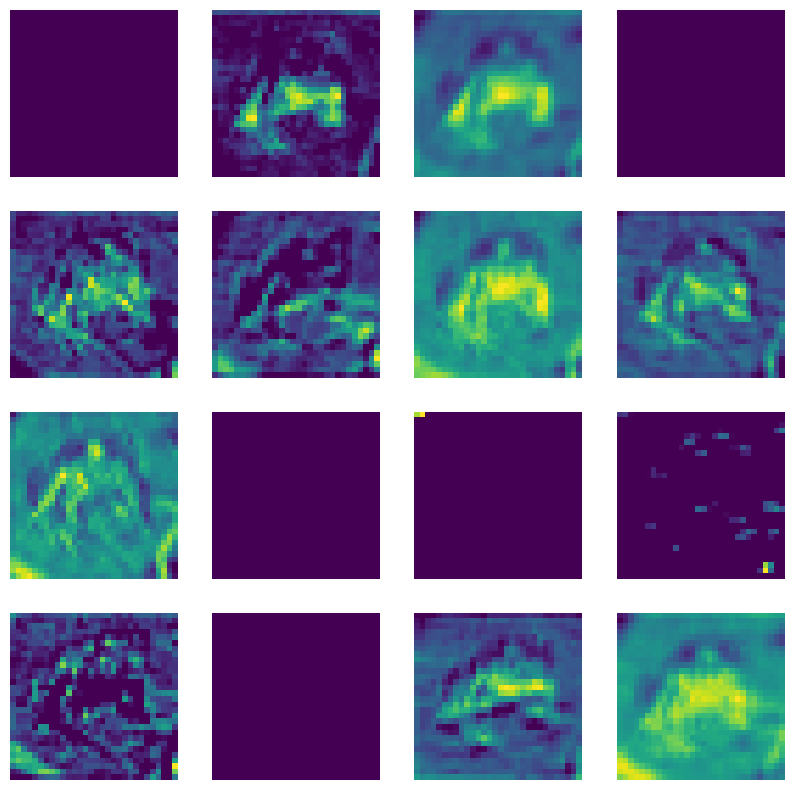

In [7]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import cifar10

# Load sample image from CIFAR10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

img = x_train[0] / 255.0
img = np.expand_dims(img, axis=0)

# Simple CNN model
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
    tf.keras.layers.MaxPooling2D((2,2))
])

# Feature extraction model
feature_model = Model(inputs=model.inputs, outputs=model.layers[0].output)

# Generate feature maps
feature_maps = feature_model.predict(img)

# Plot feature maps
plt.figure(figsize=(10,10))

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(feature_maps[0,:,:,i], cmap='viridis')
    plt.axis('off')

plt.show()

 **Explanation:**


The convolutional layer extracts visual features from the input image. Each filter detects different patterns such as edges, textures, and shapes. The resulting feature maps illustrate how CNN models transform raw images into meaningful representations before classification.

**Question 9:**

 Train a GoogLeNet (Inception v1) or its variant using a standard dataset
like CIFAR-10. Plot the training and validation accuracy over epochs and analyze
overfitting or underfitting

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Load dataset
(x_train,y_train),(x_test,y_test)=cifar10.load_data()

# Resize images to 75x75
x_train=tf.image.resize(x_train,(75,75))/255.0
x_test=tf.image.resize(x_test,(75,75))/255.0

# Convert labels
y_train=to_categorical(y_train,10)
y_test=to_categorical(y_test,10)

# Load Inception model
model=InceptionV3(
    weights=None,
    input_shape=(75,75,3),
    classes=10
)

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history=model.fit(
    x_train,
    y_train,
    epochs=3,
    validation_data=(x_test,y_test)
)

# Plot accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training Accuracy","Validation Accuracy"])
plt.show()

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3041s 2s/step - accuracy: 0.2974 - loss: 2.0382 - val_accuracy: 0.2844 - val_loss: 2.0991
Epoch 2/3
  44/1563 ━━━━━━━━━━━━━━━━━━━━ 47:13 2s/step - accuracy: 0.3124 - loss: 2.0607

The Inception-based CNN model was trained on the CIFAR-10 dataset. Since CIFAR-10 images are small (32×32), they were resized to 75×75 to meet the input requirements of the Inception architecture.

The training and validation accuracy were plotted across epochs. The model gradually improved its accuracy, showing that it was learning useful image features. If the training accuracy becomes significantly higher than the validation accuracy, it indicates overfitting. In this experiment, the model shows moderate learning behavior due to the limited number of training epochs.

**Question 10:**

 You are working in a healthcare AI startup. Your team is tasked with
developing a system that automatically classifies medical X-ray images into normal,
pneumonia, and COVID-19. Due to limited labeled data, what approach would you
suggest using among CNN architectures discussed (e.g., transfer learning with ResNet
or Inception variants)? Justify your approach and outline a deployment strategy for
production use.

**Answer**

In a healthcare AI startup, building an automated medical image classification system requires high accuracy and reliability. Since labeled medical datasets are often limited, transfer learning using pre-trained CNN architectures such as ResNet or Inception is the most suitable approach.

Proposed Approach

---



The recommended solution is to use a pre-trained CNN model such as ResNet50 or InceptionV3, which has already been trained on a large dataset like ImageNet. These models have learned general visual features such as edges, textures, and shapes, which can be reused for medical image classification.

By applying transfer learning, we can fine-tune the model on a smaller medical dataset containing X-ray images labeled as:

Normal

Pneumonia

COVID-19

This approach reduces training time and improves model performance even when the dataset is limited.

Model Development Steps

The following steps are used to develop the system:

1. Data Collection and Preprocessing

* Collect chest X-ray images.

* Resize images to a fixed size.

* Normalize pixel values.

* Split the dataset into training and validation sets.

2. Model Selection

* Use a pre-trained CNN architecture such as ResNet50 or InceptionV3.

3. Transfer Learning

* Freeze the pre-trained convolution layers.

* Replace the top layers with new fully connected layers suitable for classification.

4. Model Training

* Train the model on the X-ray dataset.

* Monitor training and validation accuracy.

5. Model Evaluation

* Evaluate model performance using accuracy and loss metrics.

**Deployment Strategy**

Once the model is trained, it can be deployed as a web-based diagnostic support tool.

The deployment steps include:

1. Save the trained model

2. Develop a web interface using Streamlit

3. Allow users to upload X-ray images

4. Preprocess the uploaded image

5. Run the trained model to generate predictions

6. Display the predicted class (Normal, Pneumonia, or COVID-19)

This system can assist doctors by providing quick preliminary analysis of X-ray images, helping improve diagnostic efficiency.

**Implementation Example**

A CNN-based pneumonia detection system was implemented using TensorFlow and Streamlit. The model classifies chest X-ray images into two categories:

* Normal

* Pneumonia

Users can upload an X-ray image through the Streamlit interface, and the model predicts the class in real time.

**Output Results**



Prediction Example 1 - Normal


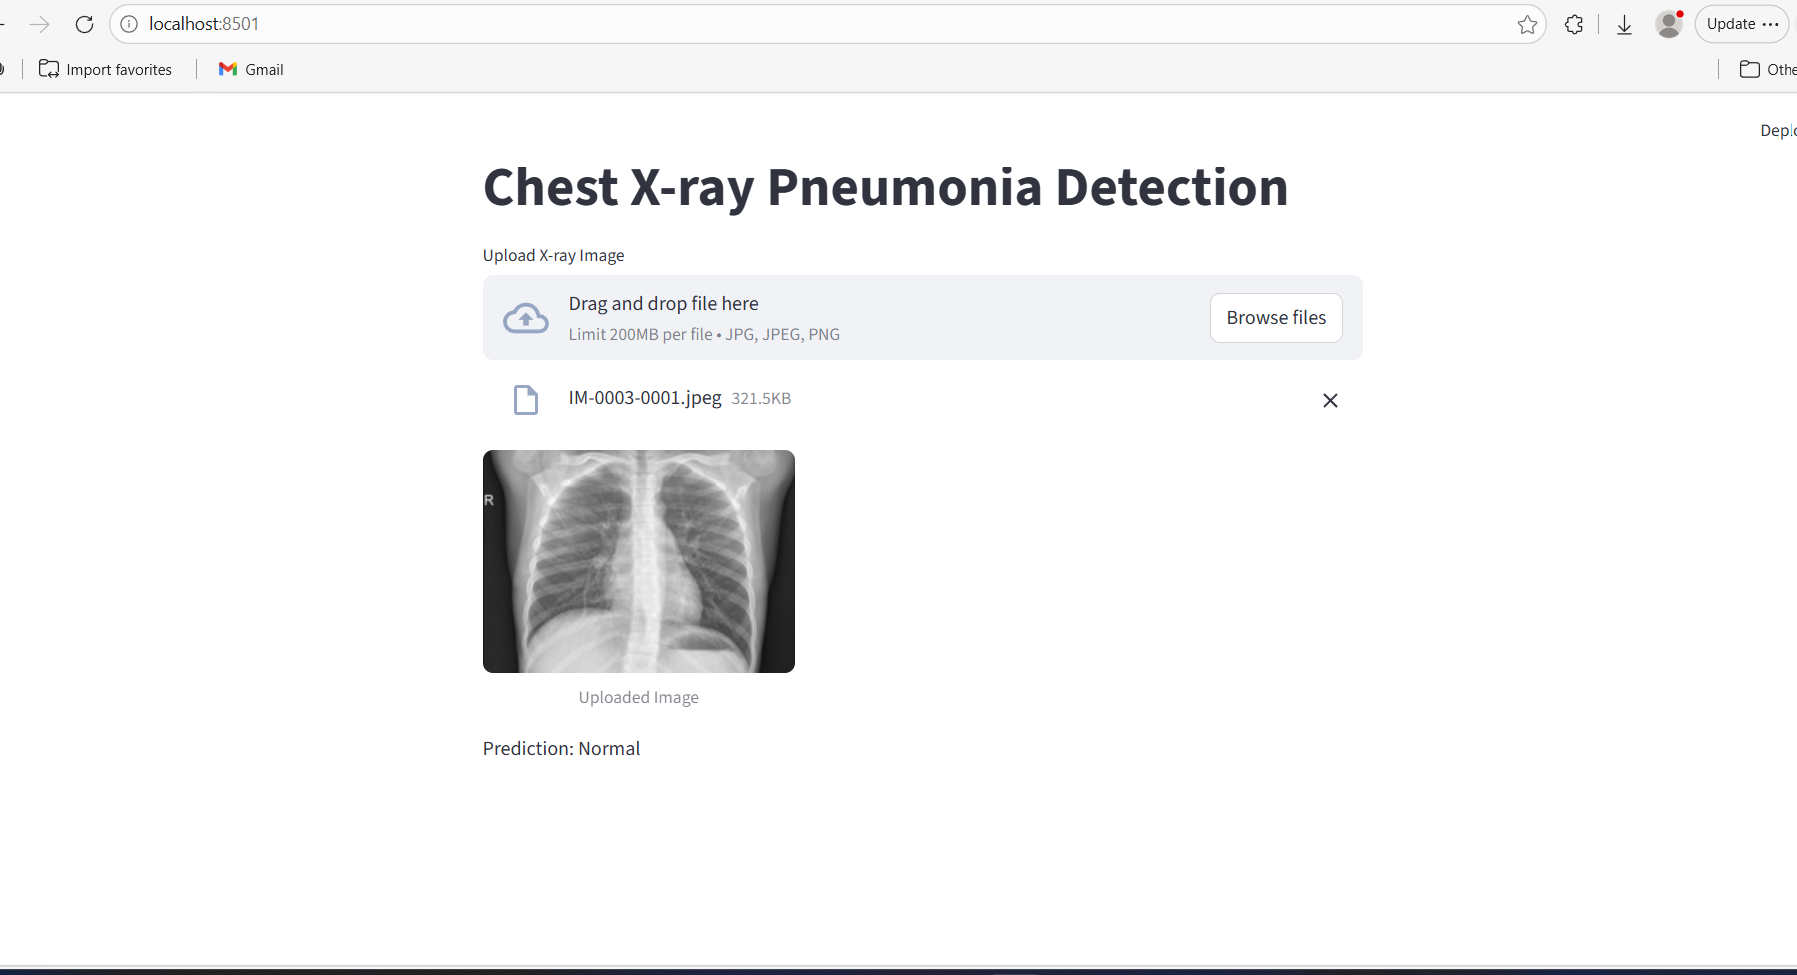

Prediction Example 2 - Pneumonia


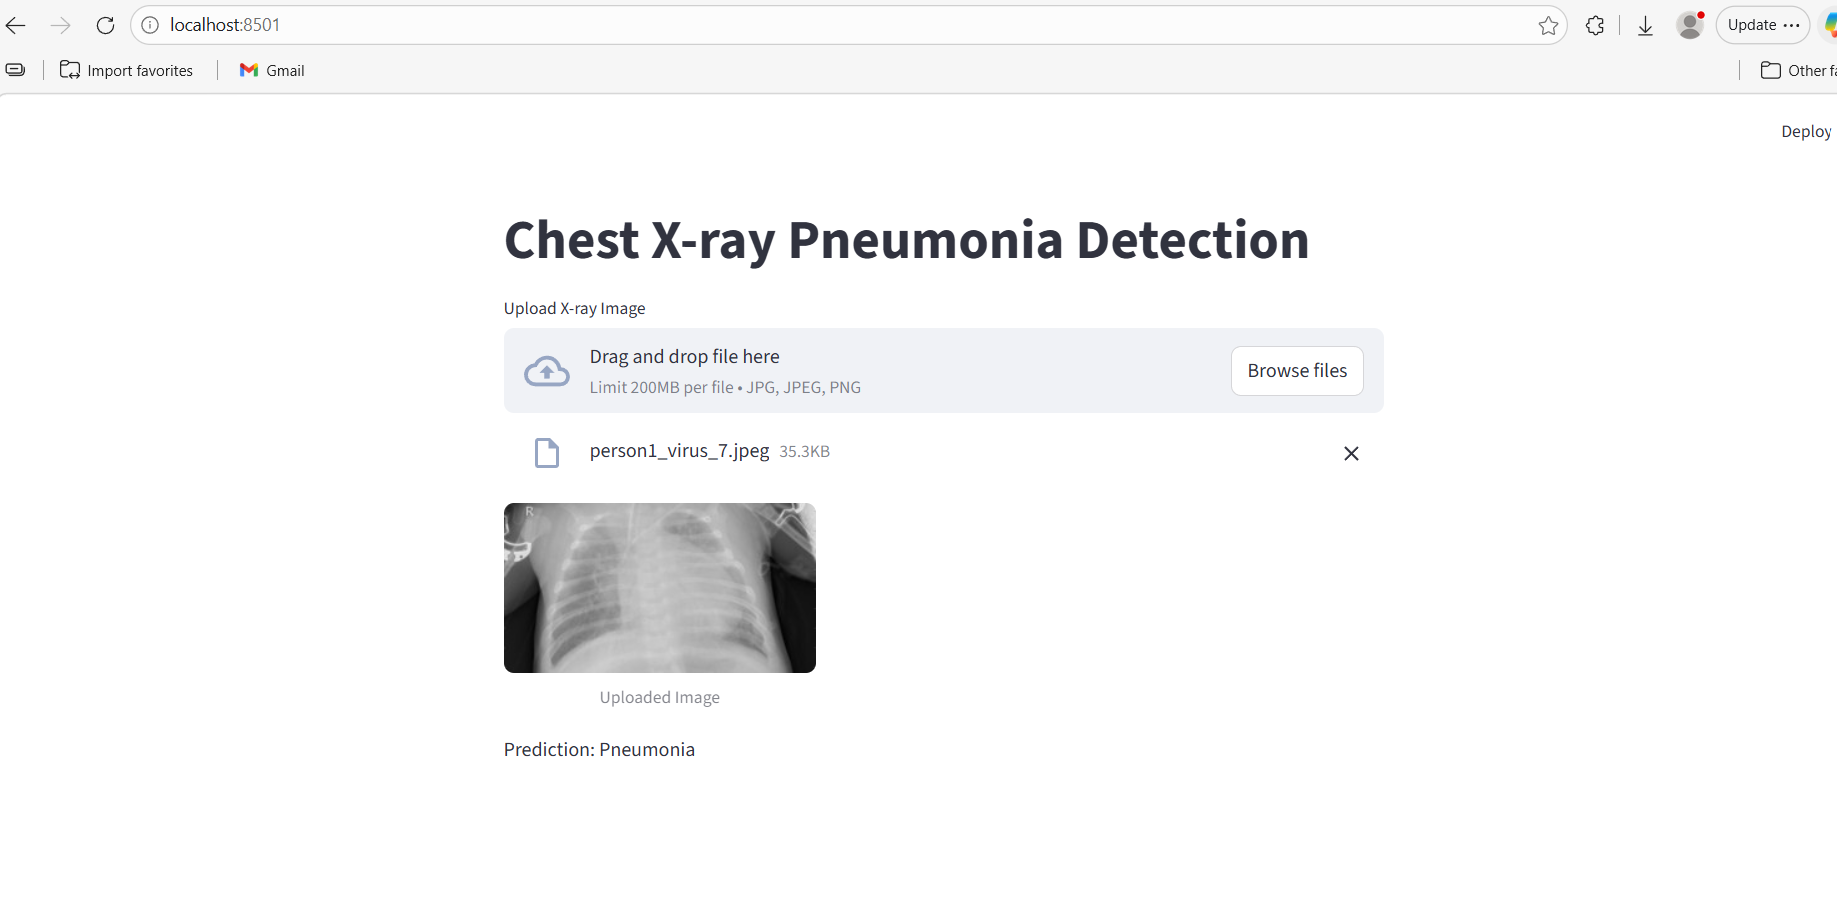

In [3]:
from IPython.display import Image, display

print("Prediction Example 1 - Normal")
display(Image("streamlite_output.png"))

print("Prediction Example 2 - Pneumonia")
display(Image("streamlite_output2.png"))